Successfully connected to SQL Server!
 Extracting data from SQL Server...
Extracted 1344 completed booking records.

 --- CUSTOMER LIFETIME VALUE (CLV) ANALYSIS ---
LoyaltyTier      AvgCLV  TotalRevenue
   Standard 6883.168240    1720792.06
     Silver 7777.227360     972153.42
       Gold 6858.121915     322331.73
   Platinum 6909.856042     331673.09


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10836\3263392890.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10836\3263392890.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LoyaltyTier', y='AvgCLV', data=final_metrics, ax=axes[0], palette='viridis')


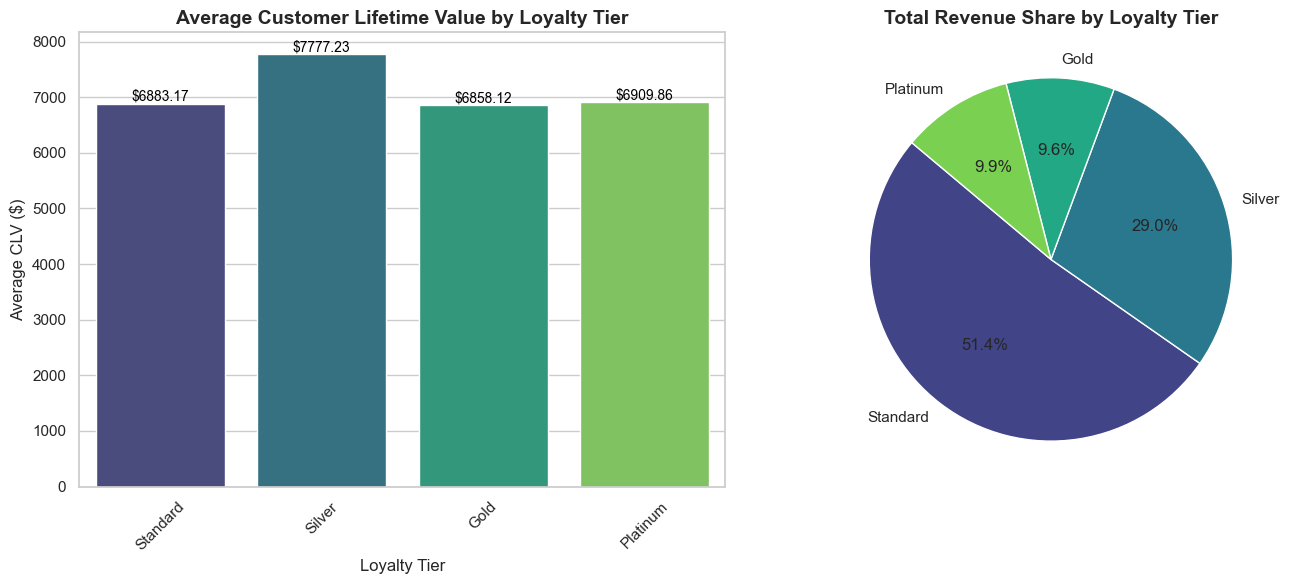


 Analysis complete! Chart saved as 'TravelCX_CLV_Analysis.png'


In [2]:
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONNECT TO SQL SERVER
server = 'DESKTOP-VKRMBR2\\SQLEXPRESS' 
database = 'TravelCx_Analytics'

# Using Windows Authentication (Trusted Connection)
conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    conn = pyodbc.connect(conn_str)
    print("Successfully connected to SQL Server!")
except Exception as e:
    print(f"Error connecting to database: {e}")
    exit()
# 2. EXTRACT DATA USING SQL
# I pull only completed bookings to calculate real revenue
query = """
SELECT 
    t.TravelerID, 
    t.LoyaltyTier, 
    b.BookingID, 
    b.TotalCost, 
    b.DepartureDate
FROM dbo.Traveler t
JOIN dbo.Booking b ON t.TravelerID = b.TravelerID
WHERE b.BookingStatus = 'Completed';
"""

print(" Extracting data from SQL Server...")
df = pd.read_sql(query, conn)
conn.close()
print(f"Extracted {len(df)} completed booking records.")
# 3. DATA ANALYSIS & CALCULATIONS (The Core Skill)
# Calculate Customer Lifetime Value (CLV) per traveler
# CLV = Total Revenue generated by a single customer over their lifetime
clv_per_customer = df.groupby(['TravelerID', 'LoyaltyTier'])['TotalCost'].sum().reset_index()
clv_per_customer.rename(columns={'TotalCost': 'CustomerLifetimeValue'}, inplace=True)

# Calculate Average CLV per Loyalty Tier
avg_clv_by_tier = clv_per_customer.groupby('LoyaltyTier')['CustomerLifetimeValue'].mean().reset_index()
avg_clv_by_tier.rename(columns={'CustomerLifetimeValue': 'AvgCLV'}, inplace=True)

# Calculate Total Revenue per Tier
total_revenue_by_tier = df.groupby('LoyaltyTier')['TotalCost'].sum().reset_index()
total_revenue_by_tier.rename(columns={'TotalCost': 'TotalRevenue'}, inplace=True)

# Merge metrics for a comprehensive view
final_metrics = pd.merge(avg_clv_by_tier, total_revenue_by_tier, on='LoyaltyTier')

# Sort by Loyalty Tier (Standard -> Platinum)
tier_order = ['Standard', 'Silver', 'Gold', 'Platinum']
final_metrics['LoyaltyTier'] = pd.Categorical(final_metrics['LoyaltyTier'], categories=tier_order, ordered=True)
final_metrics = final_metrics.sort_values('LoyaltyTier')

print("\n --- CUSTOMER LIFETIME VALUE (CLV) ANALYSIS ---")
print(final_metrics.to_string(index=False))

# 4. DATA VISUALIZATION 
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Average CLV by Loyalty Tier (Bar Chart)
sns.barplot(x='LoyaltyTier', y='AvgCLV', data=final_metrics, ax=axes[0], palette='viridis')
axes[0].set_title('Average Customer Lifetime Value by Loyalty Tier', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loyalty Tier')
axes[0].set_ylabel('Average CLV ($)')
axes[0].tick_params(axis='x', rotation=45)

# value labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# Chart 2: Total Revenue Distribution by Tier (Pie Chart)
axes[1].pie(final_metrics['TotalRevenue'], labels=final_metrics['LoyaltyTier'], autopct='%1.1f%%', 
            startangle=140, colors=sns.color_palette('viridis', 4))
axes[1].set_title('Total Revenue Share by Loyalty Tier', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('TravelCX_CLV_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Analysis complete! Chart saved as 'TravelCX_CLV_Analysis.png'")